## Step 1: Overview

* What data are you using. (2-3 lines)

We are using aerial photos taken of Allen Island from a DJI Phantom 4 drone. The dataset was created upon the acquisition of Allen Island by Colby College, with the aim of using the island as an opportunity to study oceanic phenomena, specifically, the impact of human activity on/around coastal areas in the form of trash. 

* Mention what annotation tool you used.
Due to prior experience with makesense.ai and Labelbox, we decided to go with Labelbox for its ease of use. Everything on Labelbox is hosted online, which makes it easy to collaborate as a team when it comes to labeling images, as well as sync the images so that they stay in an online project instead of having to upload images every single time we wanted to label them.


* Describe your class labels/annotations used in this notebook.

Annotations are consistent by using boxes to label trash in drone images. Our team first goes through the labeling process together, then we go through and review the images that we’ve labeled. Labelbox has a system built in where you need to go back over and review the images before they are added to the labeled data. The images are randomized, meaning that the person reviewing them is different from the person who labeled them to ensure consistency. 


* Describe the process of the best model below.

A transformer is a model that differs from traditional neural networks. It uses “attention” to detect ways even distant data elements relate to each other. It is quite standard in NLP, but less popular in Computer Vision applications.

Our Model is taken from a ViT model through Hugging Face and finetuned on trash. It was first trained on ImageNet-21k (14 million images, 21,843 classes. It was then fine tuned on a dataset of 501 glass, 594 paper, 403 cardboard, 482 plastic, 410 metal, 137 trash images.


## Step 2: Import the libraries 

In [ ]:
!pip install transformers
!pip install datasets
!pip install datasets[vision]
!pip install evaluate

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 39.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.3/190.3 KB 22.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 114.2 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.8/462.8 KB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.0/213.0 KB 26.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.0/132.0 KB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 KB 19.7 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 1.24.3
    Uninstalling urllib3-1.24.3:
      Successfully uninstalled urllib3-1.24.3
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wh

In [ ]:
#imports
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import glob
from IPython.display import display
from PIL import Image
import cv2 as cv
from google.colab.patches import cv2_imshow
from matplotlib import pyplot as plt

## Step 2: Prepare your data

* Mount your data from google drive to co-lab (feel free to use your team's folder to upload data)
* load, preprocess, normalize, one hot encoding/scaling, split data for the model

In [ ]:
# mounting our drive, so that we can access image, feel free to change directory path accrodingly 
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#download pretrained model
from transformers import AutoFeatureExtractor, AutoModelForImageClassification

extractor = AutoFeatureExtractor.from_pretrained("Aalaa/Fine_tuned_Vit_trash_classification")
model = AutoModelForImageClassification.from_pretrained("Aalaa/Fine_tuned_Vit_trash_classification")

In [ ]:
#extract features
from transformers import ViTFeatureExtractor
model_path = "Aalaa/Fine_tuned_Vit_trash_classification"
feature_extractor = ViTFeatureExtractor.from_pretrained(model_path)
print(feature_extractor)

ViTFeatureExtractor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTFeatureExtractor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



In [ ]:
#load in our own dataset (needs to be structured in specific format
#see ours for reference)

import datasets
from datasets import load_dataset, Image

dataset = load_dataset("imagefolder", data_dir="/content/drive/MyDrive/JP_CV_Notebooks/Ai island/annotations/allentrash/")

EmptyDatasetError: ignored

In [ ]:
#check to see if your training dataset imported correctly
dataset['train']

Dataset({
    features: ['image', 'label'],
    num_rows: 317
})

In [ ]:
#convert images to tensors with function
def process_example(example):
    inputs = feature_extractor(example['image'], return_tensors='pt')
    inputs['labels'] = example['label']
    return inputs

In [ ]:
#test tensor conversion
process_example(dataset['train'][0])

{'pixel_values': tensor([[[[-0.0353, -0.0196, -0.1137,  ..., -0.2157, -0.2627, -0.4118],
          [-0.0353, -0.0667, -0.0824,  ..., -0.2627, -0.2627, -0.3412],
          [-0.0824, -0.1216, -0.0980,  ..., -0.2941, -0.2784, -0.2000],
          ...,
          [-0.0667, -0.0667, -0.0588,  ...,  0.3098,  0.3176,  0.2157],
          [-0.0588, -0.0588, -0.0745,  ...,  0.3098,  0.2784,  0.2157],
          [-0.0431, -0.0667, -0.0588,  ...,  0.3333,  0.1529,  0.0039]],

         [[ 0.0353,  0.0431, -0.0588,  ..., -0.1765, -0.2235, -0.3725],
          [ 0.0353, -0.0039, -0.0353,  ..., -0.2157, -0.2235, -0.3176],
          [-0.0039, -0.0667, -0.0588,  ..., -0.2549, -0.2314, -0.1765],
          ...,
          [ 0.0980,  0.0980,  0.1059,  ...,  0.2784,  0.2784,  0.2314],
          [ 0.1059,  0.1059,  0.0980,  ...,  0.2706,  0.2549,  0.2235],
          [ 0.1216,  0.1059,  0.1059,  ...,  0.3020,  0.1529,  0.0588]],

         [[ 0.0510,  0.0353, -0.1059,  ..., -0.3098, -0.3412, -0.4745],
          [ 0

In [ ]:
#transform entire dataset to pixels

def transform(example_batch):
    # Take a list of PIL images and turn them to pixel values
    inputs = feature_extractor([x for x in example_batch['image']], return_tensors='pt')

    # Don't forget to include the labels!
    inputs['labels'] = example_batch['label']
    return inputs


In [ ]:
#transform dataset
prepared_ds = dataset.with_transform(transform)

In [ ]:
#check values
prepared_ds['train'][0:2]

{'pixel_values': tensor([[[[-0.0353, -0.0196, -0.1137,  ..., -0.2157, -0.2627, -0.4118],
          [-0.0353, -0.0667, -0.0824,  ..., -0.2627, -0.2627, -0.3412],
          [-0.0824, -0.1216, -0.0980,  ..., -0.2941, -0.2784, -0.2000],
          ...,
          [-0.0667, -0.0667, -0.0588,  ...,  0.3098,  0.3176,  0.2157],
          [-0.0588, -0.0588, -0.0745,  ...,  0.3098,  0.2784,  0.2157],
          [-0.0431, -0.0667, -0.0588,  ...,  0.3333,  0.1529,  0.0039]],

         [[ 0.0353,  0.0431, -0.0588,  ..., -0.1765, -0.2235, -0.3725],
          [ 0.0353, -0.0039, -0.0353,  ..., -0.2157, -0.2235, -0.3176],
          [-0.0039, -0.0667, -0.0588,  ..., -0.2549, -0.2314, -0.1765],
          ...,
          [ 0.0980,  0.0980,  0.1059,  ...,  0.2784,  0.2784,  0.2314],
          [ 0.1059,  0.1059,  0.0980,  ...,  0.2706,  0.2549,  0.2235],
          [ 0.1216,  0.1059,  0.1059,  ...,  0.3020,  0.1529,  0.0588]],

         [[ 0.0510,  0.0353, -0.1059,  ..., -0.3098, -0.3412, -0.4745],
          [ 0

In [ ]:
#stack data
import torch

def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.tensor([x['labels'] for x in batch])
    }

## Step 3: Model

In [ ]:
#load f1 metric
import numpy as np
from datasets import load_metric

#You can change the metrics through commenting/uncommenting this. Preferable to put it as F1.

#metric = load_metric("accuracy")
#metric = load_metric("recall")
#metric = load_metric("precision")
metric = load_metric("f1")
def compute_metrics(p):
    return metric.compute(predictions=np.argmax(p.predictions, axis=1), references=p.label_ids, average='macro')

<ipython-input-15-c91bec4d3da0>:5: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  metric = load_metric("f1")


In [ ]:
#create model
from transformers import ViTForImageClassification

labels = dataset['train'].features['label'].names
print("bloop" + str(labels))

model = ViTForImageClassification.from_pretrained(
    model_path,
    num_labels=len(labels),
    id2label={str(i): c for i, c in enumerate(labels)},
    label2id={c: str(i) for i, c in enumerate(labels)},
    ignore_mismatched_sizes=True
)

bloop['no_trash', 'trash']


Some weights of ViTForImageClassification were not initialized from the model checkpoint at Aalaa/Fine_tuned_Vit_trash_classification and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([7, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([7]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
#define training arguments and hyperparameters
from transformers import TrainingArguments

training_args = TrainingArguments(
  output_dir="./vit-base-beans",
  per_device_train_batch_size=16,
  evaluation_strategy="steps",
  num_train_epochs=10,
  fp16=False,
  save_steps=10,
  eval_steps=10,
  logging_steps=10,
  learning_rate=1e-4,
  save_total_limit=2,
  remove_unused_columns=False,
  push_to_hub=False,
  report_to='tensorboard',
  load_best_model_at_end=True,
)


/usr/local/lib/python3.8/dist-packages/torch/cuda/__init__.py:497: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [ ]:
#load in hyperparameters
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=prepared_ds["train"],
    eval_dataset=prepared_ds["validation"],
    tokenizer=feature_extractor
)


## Step 4: Training

In [ ]:
#train model
train_results = trainer.train()
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()


/usr/local/lib/python3.8/dist-packages/transformers/optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
***** Running training *****
  Num examples = 317
  Num Epochs = 4
  Instantaneous batch size per device = 16
  Total train batch size (w. parallel, distributed & accumulation) = 16
  Gradient Accumulation steps = 1
  Total optimization steps = 80
  Number of trainable parameters = 85800194


In [ ]:
trainer.save_model(output_dir="/content/drive/MyDrive/")

## Step 5: Evaluate

In [ ]:
# check metrics

#metrics
metrics = trainer.evaluate(prepared_ds['validation'])
trainer.log_metrics("eval", metrics)
trainer.save_metrics("eval", metrics)

In [ ]:
#do predictions on data
from transformers import Trainer
#returns references and predictions
trainer.predict(prepared_ds['validation'])

## Step 6: Experimentation

What other model you have tried?
*  Fully Connected
*  MLP (Multilayer perceptron)
*  Random Forest
*  Convolutional Neural Network 
*  YOLOv5 (You Only Look Once)


Any techniques used to improve model/error analysis: Hyperparameter tuning, active learning, finetuning.


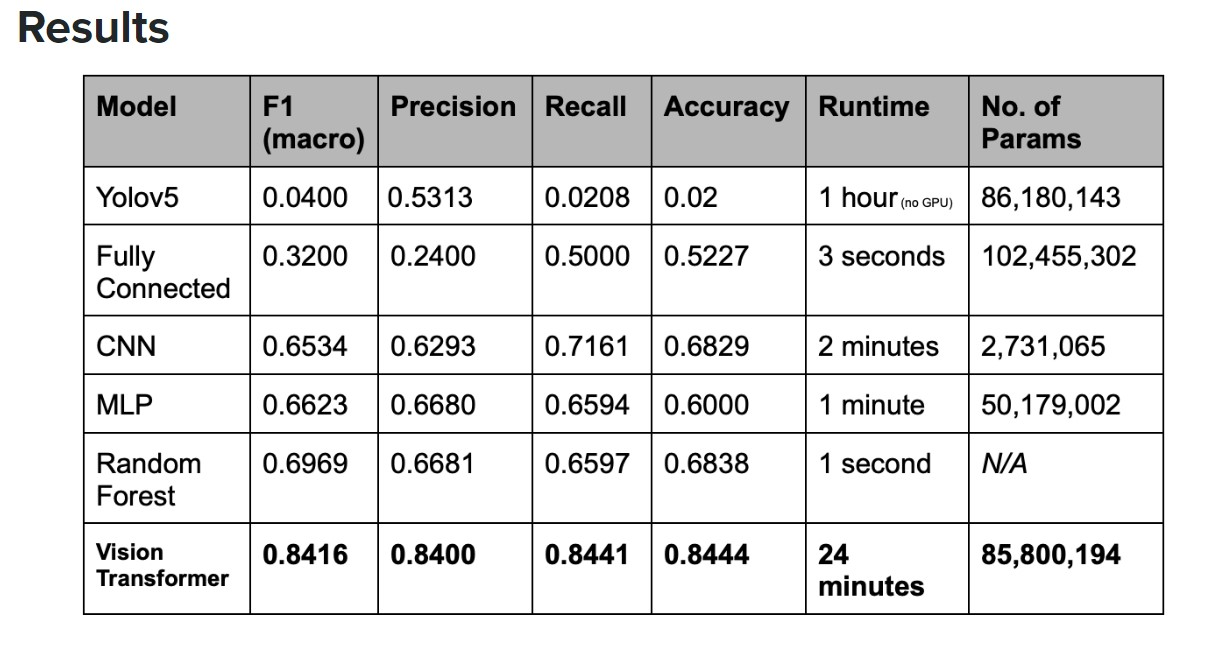

## Step 7: Our observations from the results

Size of weights from Vision Transformer is 327 MB.
With a runtime of about 24 minutes, it is our best model. I

## Step 8: Future work plan for improvement

*  Collection of more photos and labels
*  Better drone path plotting for less repeat images and clearer trash
*  Trying out more object detection models and hyperparameter tuning
